#  Analyse Exploratoire – Axe 1 : Profil des clients souscripteurs


## Objectif :
Identifier les caractéristiques personnelles et financières associées aux clients ayant souscrit (`Souscription = yes`) à un dépôt à terme.


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données nettoyées
df_large = pd.read_csv("bank-full.csv", sep=';')
df_small = pd.read_csv("bank.csv")
df_large.head()
#df_small.head()



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Nettoyage et prétraitement des Données

### Grand Dataset

In [5]:
# Suppression de la variable de fuite
df_large.drop(columns=['duration'], inplace=True)

# Suppression des lignes où le métier est inconnu
df_large = df_large[df_large['job'] != 'unknown']

# Renommage des colonnes 
df_large = df_large.rename(columns={
    'age': 'age',
    'job': 'job',
    'marital': 'marital_status',
    'education': 'education_level',
    'default': 'credit_default',
    'balance': 'annual_balance',
    'housing': 'housing_loan',
    'loan': 'personal_loan',
    'contact': 'contact_type',
    'day': 'contact_day',
    'month': 'contact_month',
    'campaign': 'current_campaign_contacts',
    'pdays': 'last_contact',
    'previous': 'previous_campaign_contacts',
    'poutcome': 'previous_campaign_outcome',
    'y': 'subscription'

})

# Export du fichier nettoyé
df_large.to_csv("bank_full_clean.csv", index=False)

print(" Données nettoyées et enregistrées dans 'bank_full_clean.csv'")
df_large_clean = pd.read_csv("bank_full_clean.csv")
df_large_clean.head()

 Données nettoyées et enregistrées dans 'bank_full_clean.csv'


,age,job,marital_status,education_level,credit_default,annual_balance,housing_loan,personal_loan,contact_type,contact_day,contact_month,current_campaign_contacts,last_contact,previous_campaign_contacts,previous_campaign_outcome,subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,35,management,married,tertiary,no,231,yes,no,unknown,5,may,1,-1,0,unknown,no


In [38]:
###
df_small = df_small.drop(columns=['duration'])
df_small = df_small[df_small['job'] != 'unknown']
df_clean_small = df_small.rename(columns={
    'age': 'age',
    'job': 'job',
    'marital': 'marital_status',
    'education': 'education_level',
    'default': 'credit_default',
    'balance': 'annual_balance',
    'housing': 'housing_loan',
    'loan': 'personal_loan',
    'contact': 'contact_type',
    'day': 'contact_day',
    'month': 'contact_month',
    'campaign': 'current_campaign_contacts',
    'pdays': 'last_contact',
    'previous': 'previous_campaign_contact',
    'poutcome': 'previous_campaign_outcome',
    'y': 'subscription'

})


# Création de la colonne contact_status

df_clean_small["contact_status"] = df_clean_small['last_contact'].apply(lambda x: 'no_contact' if x == -1 else 'already_contact')

df_clean_small.to_csv("bank_small_clean.csv", index=False)
df_clean_small.head()

,age,job,marital_status,education_level,credit_default,annual_balance,housing_loan,personal_loan,contact_type,contact_day,contact_month,current_campaign_contacts,last_contact,previous_campaign_contact,previous_campaign_outcome,deposit,contact_status
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,2,-1,0,unknown,yes,no_contact


##  Distribution de la variable cible (`Souscription`)

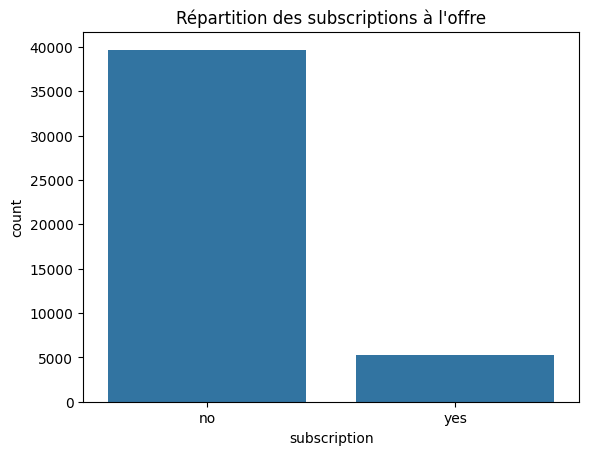

In [17]:

sns.countplot(data=df_large_clean, x='subscription')
plt.title("Répartition des subscriptions à l'offre")
plt.show()



 **Interprétation :** La majorité des clients n'ont pas souscrit à l'offre (`no`). Cette distribution déséquilibrée de la variable cible devra être prise en compte lors de la modélisation.


## Répartition de `Profession` selon `Souscription`

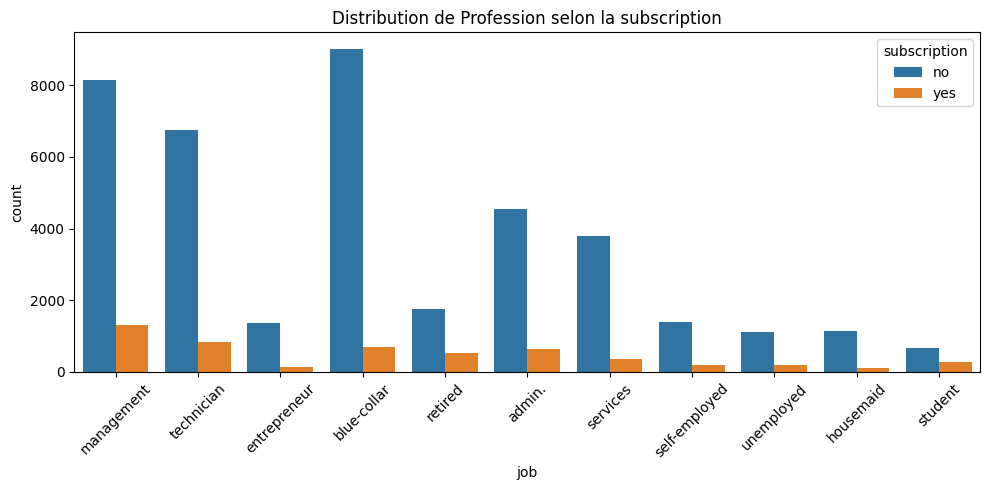

In [21]:

plt.figure(figsize=(10,5))
sns.countplot(data=df_large_clean, x='job', hue='subscription')
plt.xticks(rotation=45)
plt.title("Distribution de Profession selon la subscription")
plt.tight_layout()
plt.show()


**Interprétation :** Certaines jobs comme les retraités ou les techniciens semblent souscrire davantage. Les étudiants et ouvriers souscrivent peu.

## Répartition de `Souscription` ` selon  `Statut_Marital

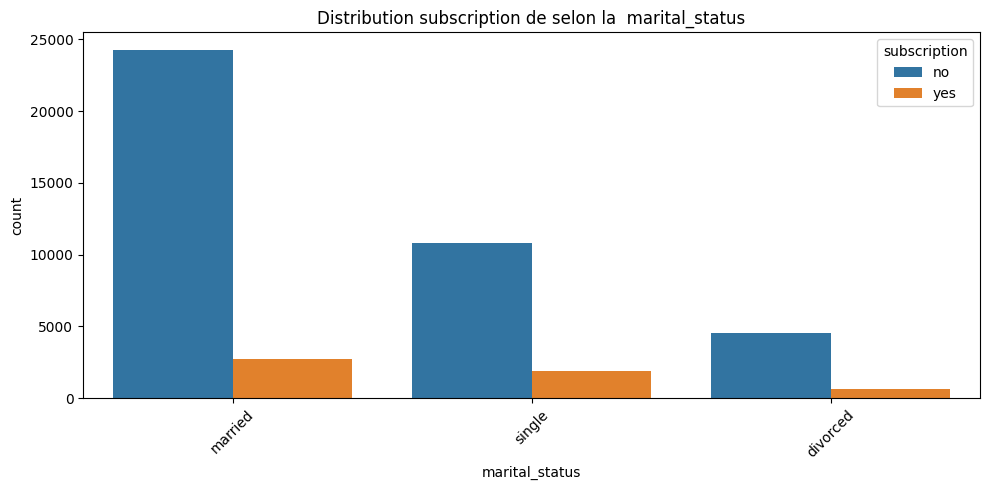

In [23]:

plt.figure(figsize=(10,5))
sns.countplot(data=df_large_clean, x='marital_status', hue='subscription')
plt.xticks(rotation=45)
plt.title("Distribution subscription de selon la  marital_status")
plt.tight_layout()
plt.show()


 **Interprétation :** Les célibataires et divorcés souscrivent proportionnellement plus que les personnes mariées.

## Répartition de `Souscription` selon `Niveau_Etudes`

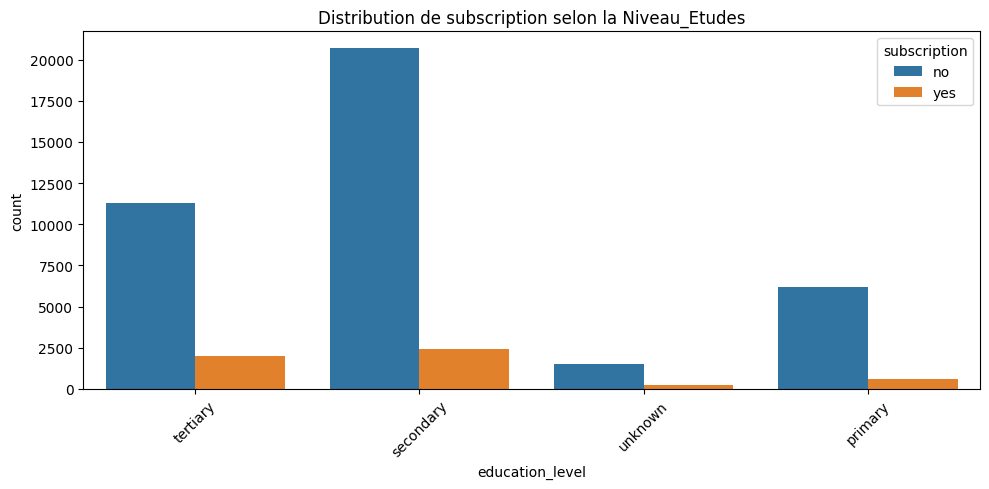

In [9]:

plt.figure(figsize=(10,5))
sns.countplot(data=df_large_clean, x='education_level', hue='subscription')
plt.xticks(rotation=45)
plt.title("Distribution de subscription selon la Niveau_Etudes")
plt.tight_layout()
plt.show()


 **Interprétation :** Les clients avec un niveau universitaire ou secondaire ont un taux de subscription plus élevé.

##  Répartition de `Souscription` ` selon `Defaut_Credit

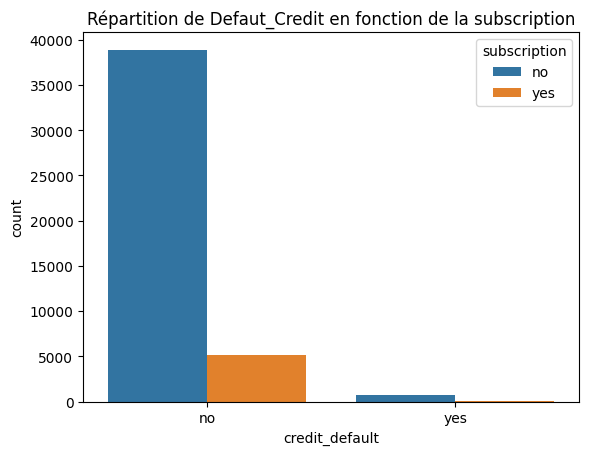

In [14]:

sns.countplot(data=df_large_clean, x='credit_default', hue='subscription')
plt.title("Répartition de Defaut_Credit en fonction de la subscription")
plt.show()


 **Interprétation :** Les clients ayant été en défaut de crédit sont rares et souscrivent peu.

##  Répartition de `Credit_Logement` selon `Souscription`

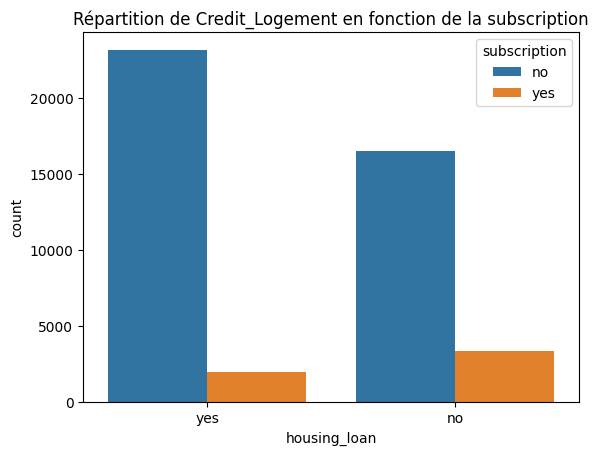

In [16]:

sns.countplot(data=df_large_clean, x='housing_loan', hue='subscription')
plt.title("Répartition de Credit_Logement en fonction de la subscription")
plt.show()


 **Interprétation :** Les clients sans crédit logement sont plus enclins à souscrire.

##  Répartition de `Credit_Personnel` selon `Souscription`

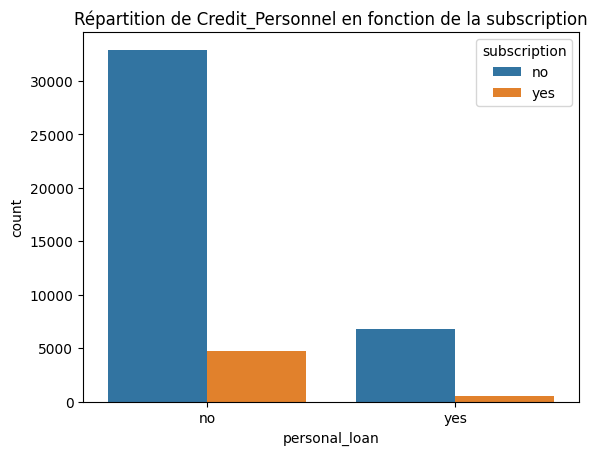

In [18]:

sns.countplot(data=df_large_clean, x='personal_loan', hue='subscription')
plt.title("Répartition de Credit_Personnel en fonction de la subscription")
plt.show()


 **Interprétation :** Les clients sans crédit personnel souscrivent davantage.

##  Solde annuel moyen (`Solde_Annuel`) selon `Souscription`

C:\Users\ndiay\AppData\Local\Temp\ipykernel_19880\708694982.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_large_clean, x='subscription', y='annual_balance', ci='sd', palette='Set2')
C:\Users\ndiay\AppData\Local\Temp\ipykernel_19880\708694982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_large_clean, x='subscription', y='annual_balance', ci='sd', palette='Set2')


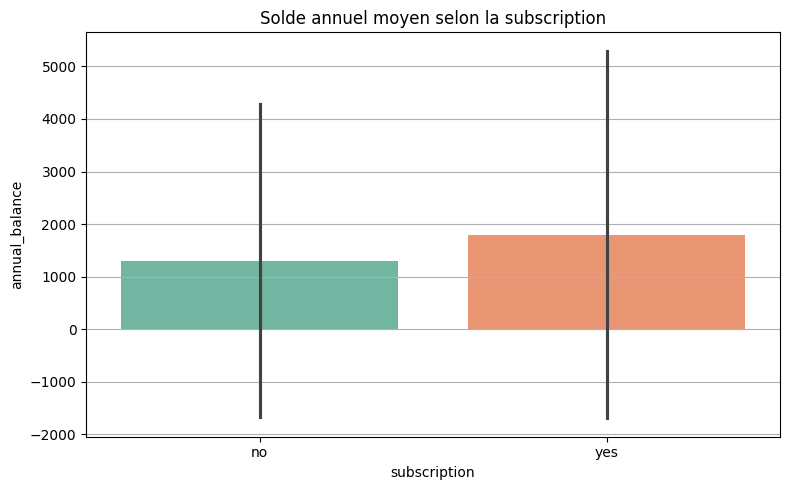

In [22]:

plt.figure(figsize=(8, 5))
sns.barplot(data=df_large_clean, x='subscription', y='annual_balance', ci='sd', palette='Set2')
plt.title("Solde annuel moyen selon la subscription")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


 **Interprétation :** Le solde annuel moyen est significativement plus élevé chez les clients ayant souscrit. Cela indique une meilleure capacité d'épargne.


##  Répartition de `Age` selon `Souscription`

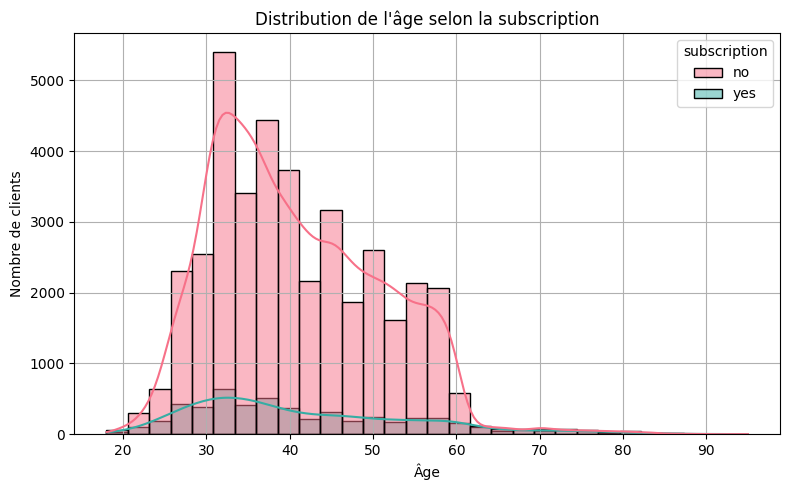

In [26]:

plt.figure(figsize=(8, 5))
sns.histplot(data=df_large_clean, x='age', hue='subscription', bins=30, kde=True, palette='husl')
plt.title("Distribution de l'âge selon la subscription")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.grid(True)
plt.tight_layout()
plt.show()


 **Interprétation :** Les clients entre 30 et 60 ans sont les plus enclins à souscrire. Les jeunes et les seniors souscrivent beaucoup moins.


##  Corrélations entre variables numériques

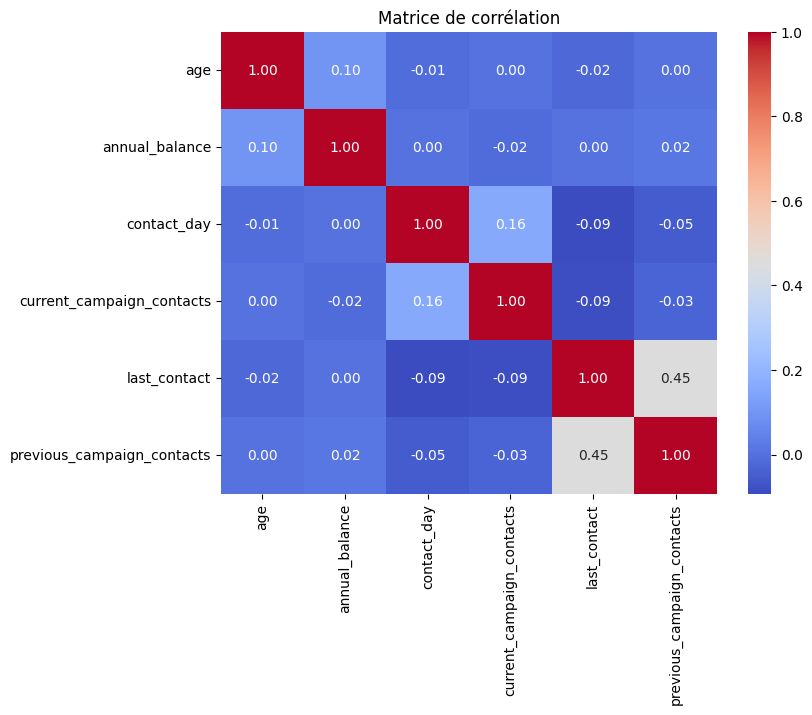

In [30]:

numeric_cols = df_large_clean.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


 **Interprétation :** Les variables numériques ne présentent pas de corrélations fortes, donc chaque variable apporte une information complémentaire utile à la modélisation.
